# Assignment 3: BBC News Classification
Group Members:

## Table of Contents
1. [Setup & Imports](#setup)
2. [Task 1: Exploratory Data Analysis](#task1)
3. [Task 2: Classification Models](#task2)
   - [2a Naive Bayes](#2a)
   - [2b kNN](#2b)
   - [2c SVM](#2c)
   - [2d ANN](#2d)
4. [Task 3: Evaluation](#task3)
   - [3a Hyperparameter Tuning](#3a)
   - [3b Best Model Comparison](#3b)
   - [3c Learning Curves](#3c)

<a id='setup'></a>
## Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.size'] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All libraries loaded successfully.')

All libraries loaded successfully.


<a id='task1'></a>
## Task 1: Exploratory Data Analysis

### Task 1(a) — Load data & extract features

We use **TF-IDF** (Term Frequency–Inverse Document Frequency) vectorization.
- `TfidfVectorizer` is fit **only on train**, then applied to test (avoiding data leakage).
- Parameters: `min_df=2` removes very rare tokens; `sublinear_tf=True` dampens term frequency.

In [2]:
# ── Load datasets ────────────────────────────────────────────
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test  shape: {test_df.shape}')
print('\nColumn names:', train_df.columns.tolist())
print('\nClass distribution (train):')
print(train_df['Category'].value_counts())

Train shape: (428, 3)
Test  shape: (106, 3)

Column names: ['Id', 'Article', 'Category']

Class distribution (train):
Category
tech             216
entertainment    212
Name: count, dtype: int64


In [3]:
# ── TF-IDF vectorization ─────────────────────────────────────
vectorizer = TfidfVectorizer(
    min_df=2,           # ignore terms appearing in <2 docs
    sublinear_tf=True,  # apply log(1+tf) to dampen freq
    max_features=10000  # cap vocabulary size
)

X_train = vectorizer.fit_transform(train_df['Article'])  # fit + transform
X_test  = vectorizer.transform(test_df['Article'])       # transform only

y_train = train_df['Category'].values
y_test  = test_df['Category'].values

feature_names = vectorizer.get_feature_names_out()

print(f'Train: {X_train.shape[0]} articles, {X_train.shape[1]} features')
print(f'Test : {X_test.shape[0]}  articles, {X_test.shape[1]}  features')

Train: 428 articles, 7366 features
Test : 106  articles, 7366  features


In [4]:
# ── Show 5 example articles with top-5 TF-IDF features ───────
sample_rows = []
for idx in range(5):
    article_vec = X_train[idx]
    # Get indices of top-5 TF-IDF scores for this article
    top_indices = article_vec.toarray()[0].argsort()[-5:][::-1]
    top_features = [(feature_names[i], round(article_vec[0, i], 4)) for i in top_indices]
    sample_rows.append({
        'Id':        train_df.iloc[idx]['Id'],
        'Category':  train_df.iloc[idx]['Category'],
        'Article snippet': train_df.iloc[idx]['Article'][:80] + '...',
        'Top-5 TF-IDF features': str(top_features)
    })

sample_df = pd.DataFrame(sample_rows)
sample_df

,Id,Category,Article snippet,Top-5 TF-IDF features
0,1976,tech,lifestyle governs mobile choice faster better ...,"[('bjorn', np.float64(0.2035)), ('ericsson', n..."
1,1797,entertainment,french honour director parker british film dir...,"[('parker', np.float64(0.2447)), ('alan', np.f..."
2,1866,entertainment,fockers fuel festive film chart comedy meet fo...,"[('fockers', np.float64(0.2453)), ('meet', np...."
3,1153,entertainment,housewives lift channel 4 ratings debut us tel...,"[('housewives', np.float64(0.2433)), ('compari..."
4,342,entertainment,u2 desire number one u2 three prestigious gram...,"[('bono', np.float64(0.1451)), ('u2', np.float..."


### Task 1(b) — Term frequency analysis

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Use CountVectorizer for raw frequency analysis (TF-IDF not ideal for raw counts)
count_vec = CountVectorizer(min_df=2, max_features=10000)
X_count   = count_vec.fit_transform(train_df['Article'])
count_feature_names = count_vec.get_feature_names_out()

# Total term frequencies across all documents
total_freq = np.asarray(X_count.sum(axis=0)).ravel()
top50_idx  = total_freq.argsort()[-50:][::-1]
top50_words = count_feature_names[top50_idx]
top50_freq  = total_freq[top50_idx]

# Per-class frequencies
classes = train_df['Category'].unique()
class_freq = {}
for cls in classes:
    mask = train_df['Category'] == cls
    X_cls = count_vec.transform(train_df[mask]['Article'])
    freq  = np.asarray(X_cls.sum(axis=0)).ravel()
    class_freq[cls] = freq

print('Term frequency analysis ready.')

Term frequency analysis ready.


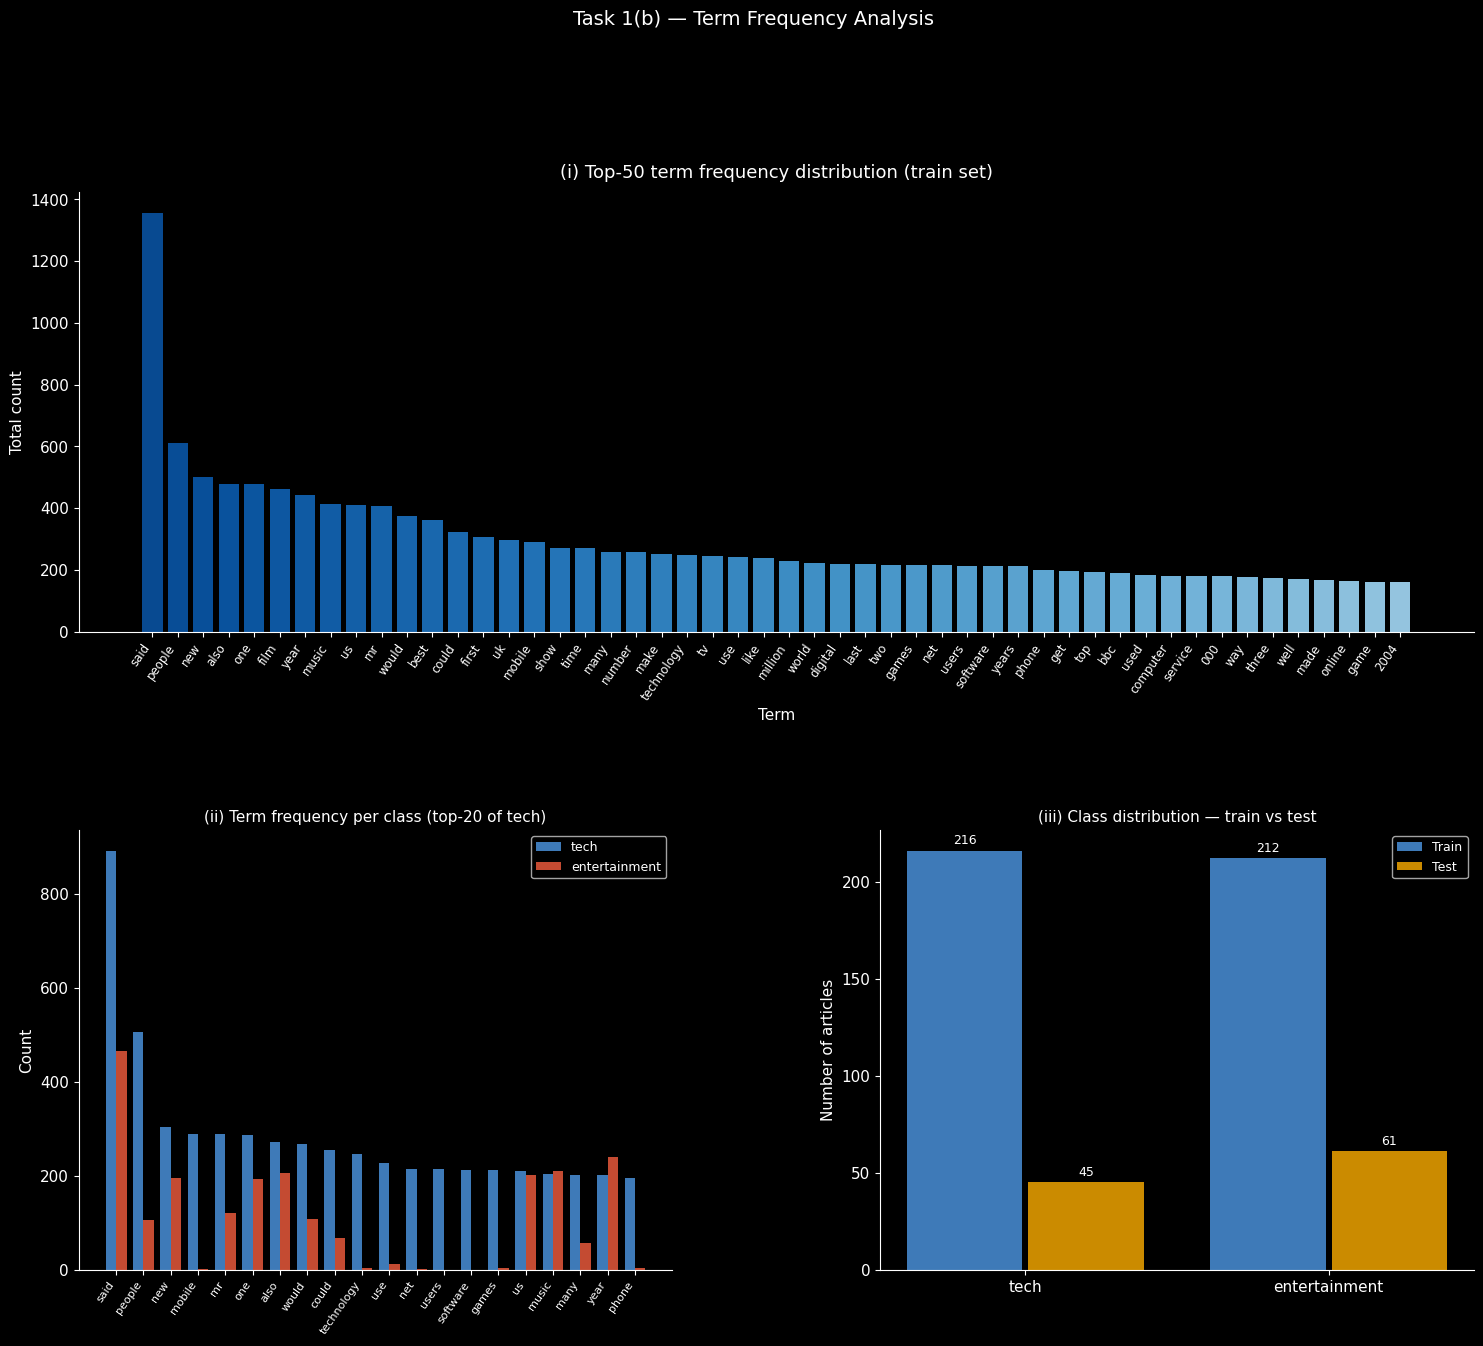

Task 1 complete.


In [6]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot (i): Top-50 overall term frequency ───────────────────
ax1 = fig.add_subplot(gs[0, :])
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 50))[::-1]
bars = ax1.bar(range(50), top50_freq, color=colors, edgecolor='none')
ax1.set_xticks(range(50))
ax1.set_xticklabels(top50_words, rotation=55, ha='right', fontsize=8.5)
ax1.set_title('(i) Top-50 term frequency distribution (train set)', fontsize=13, pad=10)
ax1.set_xlabel('Term')
ax1.set_ylabel('Total count')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Plot (ii): Per-class top-20 term frequency ────────────────
ax2 = fig.add_subplot(gs[1, 0])
palette = {'tech': '#4A90D9', 'entertainment': '#E8593C'}
top20_per_class = 20
x = np.arange(top20_per_class)
width = 0.38

# Find union of top-20 words per class
all_top_words = set()
for cls in classes:
    top_idx = class_freq[cls].argsort()[-top20_per_class:][::-1]
    all_top_words.update(count_feature_names[top_idx])

# For plotting: use top-20 words from class[0]
cls0, cls1 = classes[0], classes[1]
top_idx0   = class_freq[cls0].argsort()[-top20_per_class:][::-1]
top_words0 = count_feature_names[top_idx0]
freq0_vals = class_freq[cls0][top_idx0]
freq1_vals = class_freq[cls1][[np.where(count_feature_names == w)[0][0]
                                if w in count_feature_names else 0
                                for w in top_words0]]

ax2.bar(x - width/2, freq0_vals, width, label=cls0,
        color=palette.get(cls0, '#4A90D9'), alpha=0.85)
ax2.bar(x + width/2, freq1_vals, width, label=cls1,
        color=palette.get(cls1, '#E8593C'), alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(top_words0, rotation=55, ha='right', fontsize=8)
ax2.set_title(f'(ii) Term frequency per class (top-20 of {cls0})', fontsize=11)
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Plot (iii): Class distribution ───────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
train_counts = train_df['Category'].value_counts()
test_counts  = test_df['Category'].value_counts()
cls_labels   = train_counts.index.tolist()
x2 = np.arange(len(cls_labels))

b1 = ax3.bar(x2 - 0.2, [train_counts.get(c, 0) for c in cls_labels],
             0.38, label='Train', color='#4A90D9', alpha=0.85)
b2 = ax3.bar(x2 + 0.2, [test_counts.get(c, 0) for c in cls_labels],
             0.38, label='Test',  color='#F0A500', alpha=0.85)
ax3.set_xticks(x2)
ax3.set_xticklabels(cls_labels, fontsize=11)
ax3.set_title('(iii) Class distribution — train vs test', fontsize=11)
ax3.set_ylabel('Number of articles')
ax3.legend(fontsize=9)
for bar in list(b1) + list(b2):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.suptitle('Task 1(b) — Term Frequency Analysis', fontsize=14, y=1.01)
plt.savefig('task1b_eda.png', bbox_inches='tight', dpi=120)
plt.show()
print('Task 1 complete.')

**Task 1 observation:** [Describe what you see in the plots — e.g. class balance, dominant terms per class, etc.]

<a id='task2'></a>
## Task 2: Classification Models

**Note on dimensionality reduction for decision boundary plots:**  
The original TF-IDF feature space has thousands of dimensions. We apply **PCA** to project to 2D *solely for visualization*. The PCA model is fit on `X_train` and applied to `X_test` consistently. The decision boundary classifiers are retrained on these 2D representations.

In [7]:
# ── Shared PCA for all decision boundary plots ────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train.toarray())
X_test_2d  = pca.transform(X_test.toarray())

explained = pca.explained_variance_ratio_
print(f'PCA variance explained: PC1={explained[0]:.3f}, PC2={explained[1]:.3f}, '
      f'total={sum(explained):.3f}')

# Encode labels as integers for decision boundary mesh
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print('Classes:', le.classes_)

PCA variance explained: PC1=0.019, PC2=0.012, total=0.031
Classes: ['entertainment' 'tech']


In [8]:
def plot_decision_boundary(ax, clf, X_2d, y_enc, title, cmap_bg='RdBu', alpha=0.35):
    """Plot 2D decision boundary with scatter overlay."""
    h   = 0.05
    pad = 0.5
    x_min, x_max = X_2d[:, 0].min() - pad, X_2d[:, 0].max() + pad
    y_min, y_max = X_2d[:, 1].min() - pad, X_2d[:, 1].max() + pad
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    if Z.dtype == object:                     # string labels → encode
        Z = le.transform(Z)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=alpha, cmap=cmap_bg)
    colors = ['#E8593C', '#4A90D9']
    for cls_idx, cls_name in enumerate(le.classes_):
        mask = y_enc == cls_idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors[cls_idx], label=cls_name,
                   s=18, alpha=0.7, edgecolors='none')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

<a id='2a'></a>
### Task 2(a) — Naive Bayes

In [10]:
# ── Train NB on full TF-IDF features ─────────────────────────
# Note: MultinomialNB requires non-negative features.
# TF-IDF values are non-negative, so this works directly.
nb = MultinomialNB(alpha=1.0)   # alpha=1.0 is Laplace smoothing
nb.fit(X_train, y_train)

print('NB train F1:', round(f1_score(y_train, nb.predict(X_train), average='macro')),4)
print('NB test  F1:', round(f1_score(y_test,  nb.predict(X_test),  average='macro')),4)

NB train F1: 1 4
NB test  F1: 1 4


NB classes order: ['entertainment' 'tech']


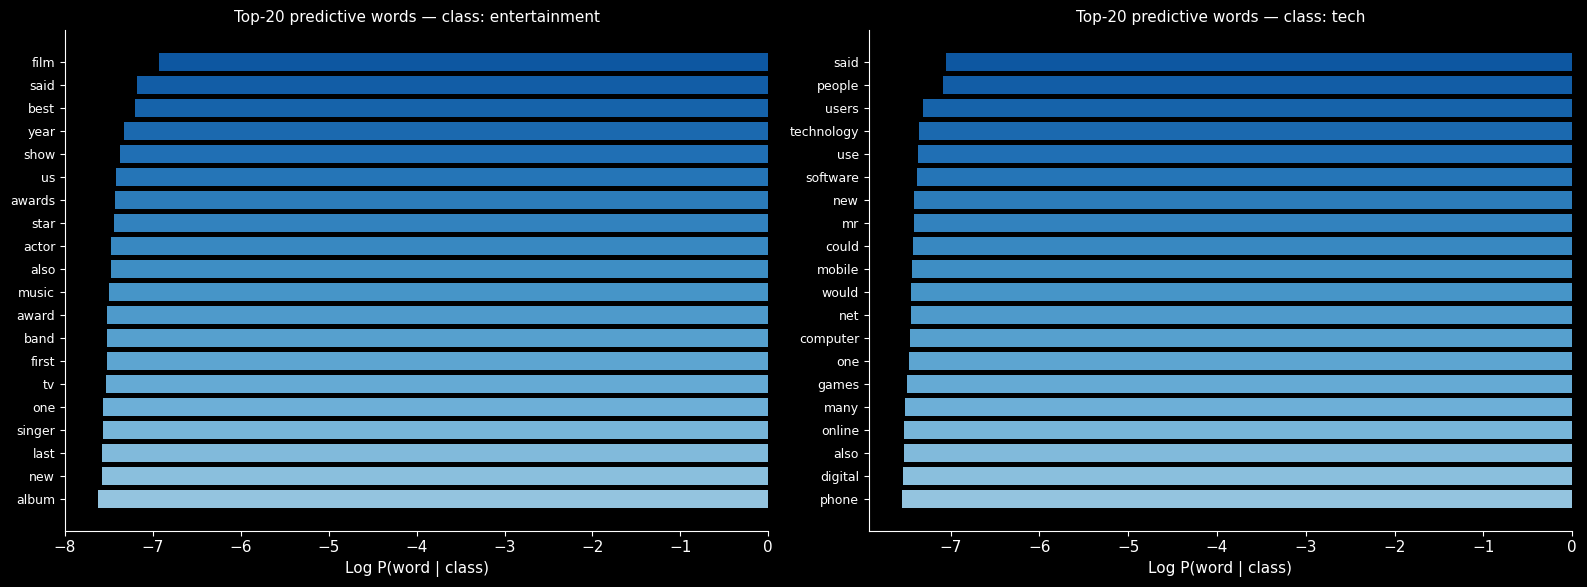

In [11]:
# ── Top-20 most predictive words per class ────────────────────
# nb.feature_log_prob_ shape: (n_classes, n_features)
# nb.classes_ tells us which index = which class
log_probs = nb.feature_log_prob_          # log P(word | class)
classes_nb = nb.classes_
print('NB classes order:', classes_nb)

n_top = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, cls in enumerate(classes_nb):
    top_idx   = log_probs[i].argsort()[-n_top:][::-1]
    top_words = feature_names[top_idx]
    top_vals  = log_probs[i][top_idx]

    colors = plt.cm.Blues(np.linspace(0.4, 0.85, n_top))[::-1]
    axes[i].barh(range(n_top), top_vals, color=colors)
    axes[i].set_yticks(range(n_top))
    axes[i].set_yticklabels(top_words, fontsize=9)
    axes[i].set_title(f'Top-20 predictive words — class: {cls}', fontsize=11)
    axes[i].set_xlabel('Log P(word | class)')
    axes[i].invert_yaxis()
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('task2a_top20.png', bbox_inches='tight', dpi=120)
plt.show()

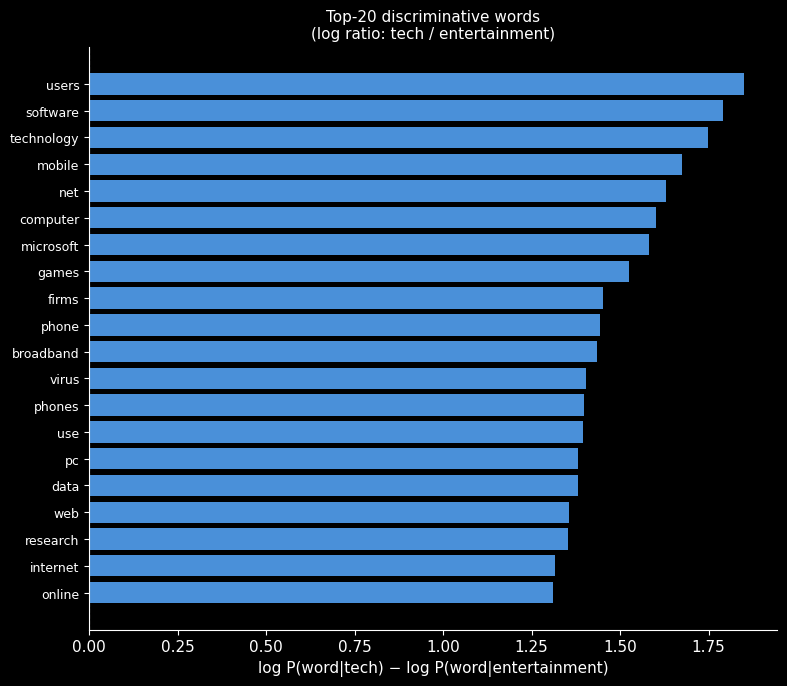


Top-20 discriminative words (tech vs entertainment):
  users                 log-ratio = 1.851
  software              log-ratio = 1.790
  technology            log-ratio = 1.750
  mobile                log-ratio = 1.675
  net                   log-ratio = 1.630
  computer              log-ratio = 1.603
  microsoft             log-ratio = 1.582
  games                 log-ratio = 1.525
  firms                 log-ratio = 1.451
  phone                 log-ratio = 1.443
  broadband             log-ratio = 1.436
  virus                 log-ratio = 1.403
  phones                log-ratio = 1.399
  use                   log-ratio = 1.394
  pc                    log-ratio = 1.382
  data                  log-ratio = 1.381
  web                   log-ratio = 1.355
  research              log-ratio = 1.354
  internet              log-ratio = 1.316
  online                log-ratio = 1.310


In [12]:
# ── Top-20 most discriminative words ─────────────────────────
# Ratio P(word|tech) / P(word|entertainment)
# In log space: log_prob[tech] - log_prob[entertainment]

# Find index of each class
idx_tech = np.where(classes_nb == 'tech')[0][0]
idx_ent  = np.where(classes_nb == 'entertainment')[0][0]

# Log ratio: positive = more likely in tech, negative = more in entertainment
log_ratio    = log_probs[idx_tech] - log_probs[idx_ent]
top_disc_idx = log_ratio.argsort()[-n_top:][::-1]   # highest ratio = most tech-leaning
top_disc_words = feature_names[top_disc_idx]
top_disc_vals  = log_ratio[top_disc_idx]

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#4A90D9' if v > 0 else '#E8593C' for v in top_disc_vals]
ax.barh(range(n_top), top_disc_vals, color=colors)
ax.set_yticks(range(n_top))
ax.set_yticklabels(top_disc_words, fontsize=9)
ax.set_title('Top-20 discriminative words\n(log ratio: tech / entertainment)', fontsize=11)
ax.set_xlabel('log P(word|tech) − log P(word|entertainment)')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('task2a_discriminative.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nTop-20 discriminative words (tech vs entertainment):')
for w, v in zip(top_disc_words, top_disc_vals):
    print(f'  {w:20s}  log-ratio = {v:.3f}')

**Task 2(a) Analysis:**

- **Top-20 predictive words:** These are the words with the highest log P(word|class) for each class. However, they may include common words shared across classes (e.g. high-frequency function words), so they don't necessarily *distinguish* the two classes.

- **Top-20 discriminative words:** These maximize the ratio P(word|tech)/P(word|entertainment). Words like `software`, `mobile`, `broadband` appear strongly tech-leaning, while `film`, `award`, `chart` lean toward entertainment. **The discriminative list better describes the two classes** because it explicitly contrasts them — a word high in both classes would have a near-zero log-ratio and would not appear here.

<a id='2b'></a>
### Task 2(b) — kNN

In [16]:
# ── Train kNN on 2D PCA features (for visualization) ─────────
# Choice: k=7, metric=euclidean — reasonable balance of bias/variance
K_CHOICE = 7
METRIC_CHOICE = 'euclidean'

knn_vis = KNeighborsClassifier(n_neighbors=K_CHOICE, metric=METRIC_CHOICE)
knn_vis.fit(X_train_2d, y_train)

# Full-feature kNN for evaluation
knn_full = KNeighborsClassifier(n_neighbors=K_CHOICE, metric=METRIC_CHOICE)
knn_full.fit(X_train, y_train)
print('kNN (full features) test F1:', round(f1_score(y_test, knn_full.predict(X_test), average='macro'),4))

kNN (full features) test F1: 0.9808


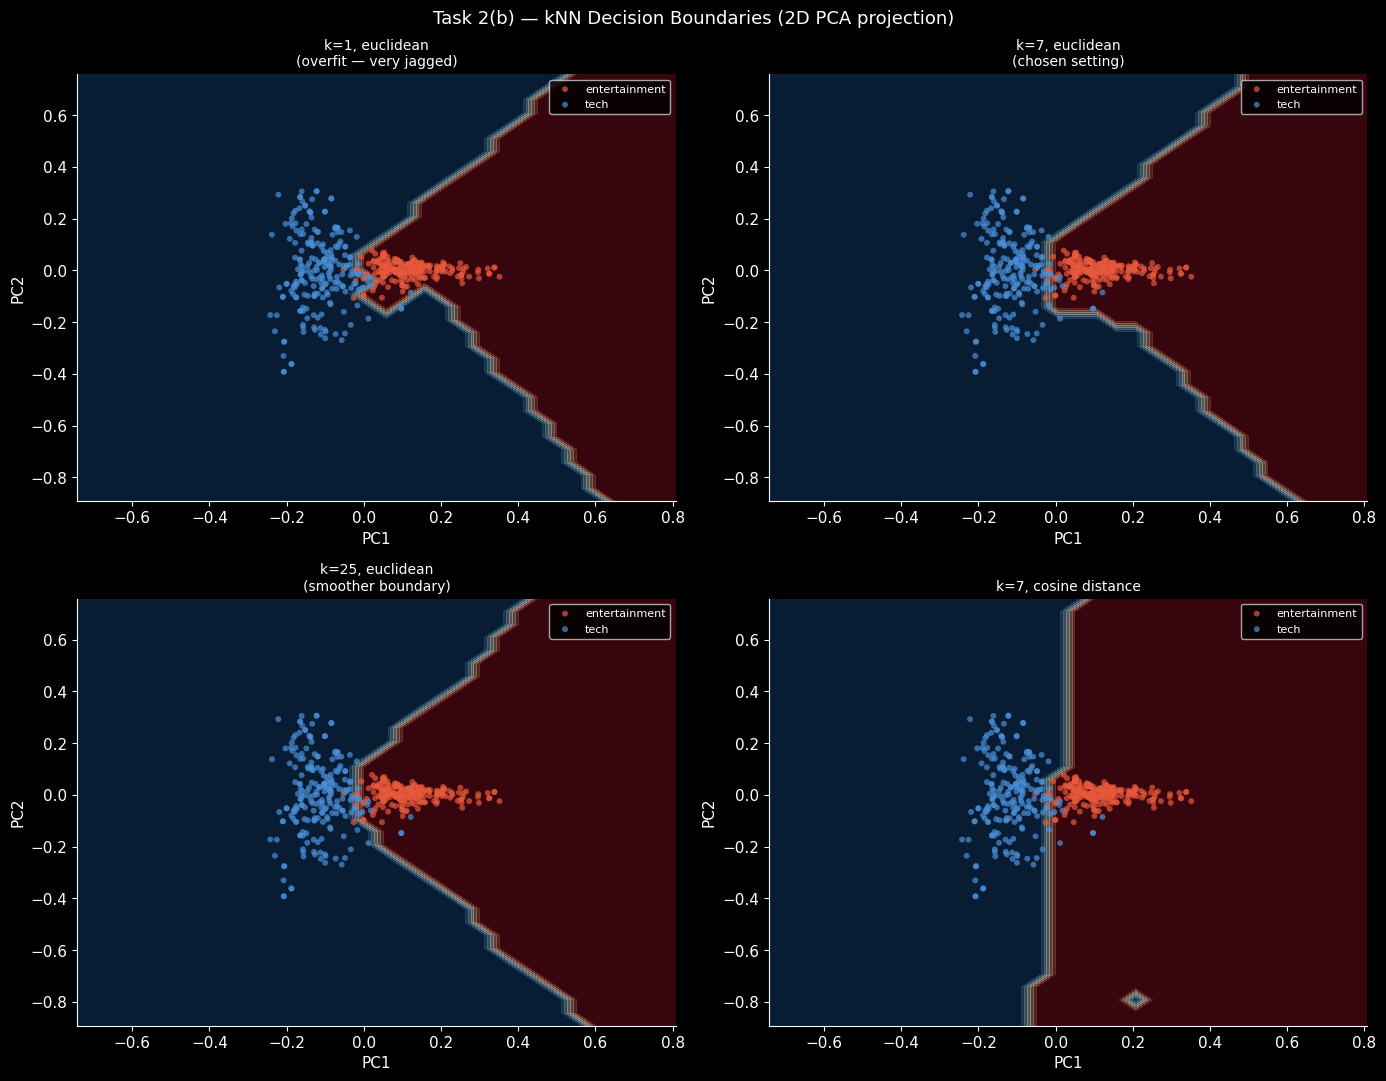

In [17]:
# ── Decision boundary: compare k=1, 7, 25 + two metrics ──────
configs = [
    (1,  'euclidean', 'k=1, euclidean\n(overfit — very jagged)'),
    (7,  'euclidean', 'k=7, euclidean\n(chosen setting)'),
    (25, 'euclidean', 'k=25, euclidean\n(smoother boundary)'),
    (7,  'cosine',    'k=7, cosine distance'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

for ax, (k, metric, title) in zip(axes, configs):
    clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
    clf.fit(X_train_2d, y_train)
    plot_decision_boundary(ax, clf, X_train_2d, y_train_enc, title)

plt.suptitle('Task 2(b) — kNN Decision Boundaries (2D PCA projection)', fontsize=13)
plt.tight_layout()
plt.savefig('task2b_knn.png', bbox_inches='tight', dpi=120)
plt.show()

**Task 2(b) Analysis:**

- **Impact of k:** Small k (e.g. k=1) creates very irregular, jagged decision boundaries that overfit to individual training points. As k increases, the boundary becomes smoother and more generalizable, but may underfit if k is too large.

- **Impact of distance metric:** Euclidean distance treats all feature dimensions equally. Cosine distance measures the *angle* between vectors — often better for text data where direction (topic) matters more than magnitude (document length). In TF-IDF space, cosine similarity is particularly natural.

<a id='2c'></a>
### Task 2(c) — SVM

In [19]:
# ── SVM full-feature models (for final evaluation) ────────────
svm_linear_full = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)
svm_rbf_full    = SVC(kernel='rbf',    C=1e6, gamma=0.1, random_state=RANDOM_STATE)
svm_linear_full.fit(X_train, y_train)
svm_rbf_full.fit(X_train, y_train)
print('SVM linear test F1:', round(f1_score(y_test, svm_linear_full.predict(X_test), average='macro'),4))
print('SVM RBF    test F1:', round(f1_score(y_test, svm_rbf_full.predict(X_test),    average='macro'),4))

SVM linear test F1: 1.0
SVM RBF    test F1: 1.0


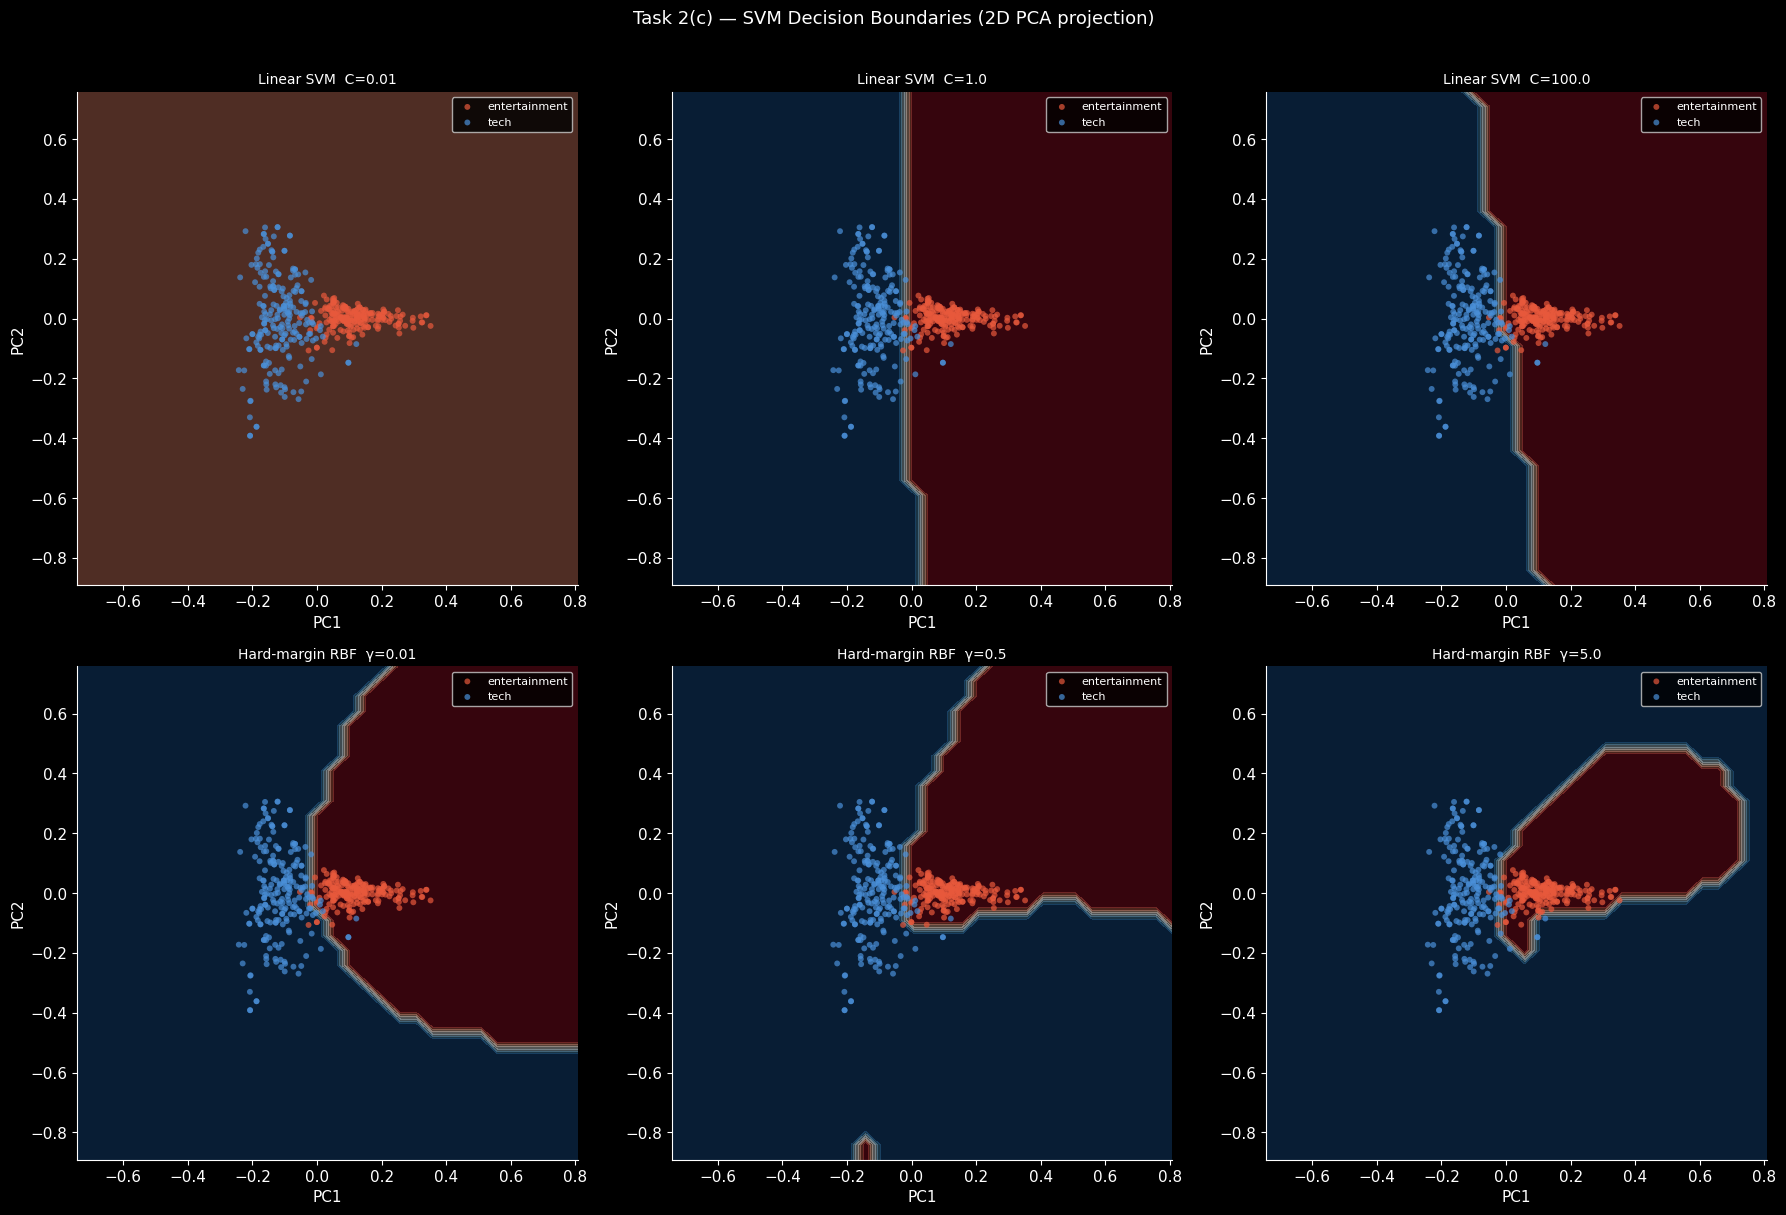

In [20]:
# ── Decision boundaries: vary C for linear, vary gamma for RBF ─
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 0: soft-margin linear SVM with different C values
C_values = [0.01, 1.0, 100.0]
for ax, C in zip(axes[0], C_values):
    clf = SVC(kernel='linear', C=C, random_state=RANDOM_STATE)
    clf.fit(X_train_2d, y_train)
    plot_decision_boundary(ax, clf, X_train_2d, y_train_enc,
                           f'Linear SVM  C={C}')

# Row 1: hard-margin RBF SVM with different gamma (σ) values
gamma_values = [0.01, 0.5, 5.0]
for ax, g in zip(axes[1], gamma_values):
    clf = SVC(kernel='rbf', C=1e6, gamma=g, random_state=RANDOM_STATE)
    clf.fit(X_train_2d, y_train)
    plot_decision_boundary(ax, clf, X_train_2d, y_train_enc,
                           f'Hard-margin RBF  γ={g}')

plt.suptitle('Task 2(c) — SVM Decision Boundaries (2D PCA projection)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('task2c_svm.png', bbox_inches='tight', dpi=120)
plt.show()

**Task 2(c) Analysis:**

- **Impact of C (soft-margin linear SVM):** C controls the trade-off between maximizing the margin and minimizing misclassification. Small C (e.g. 0.01) allows many misclassifications — wide margin, simpler boundary. Large C (e.g. 100) penalizes misclassifications heavily — narrow margin, boundary hugs training points more closely and may overfit.

- **Impact of γ (RBF kernel):** γ = 1/(2σ²) controls the kernel width. Small γ (large σ) = each training point has broad influence → smooth, simple boundary. Large γ (small σ) = narrow influence → very wiggly boundary that memorizes individual points (overfitting).

<a id='2d'></a>
### Task 2(d) — ANN

In [21]:
# ── Train ANN with varying hidden units h ────────────────────
# Hyperparameters as specified:
#   - learning_rate = 0.01
#   - max_iter = 100 epochs
#   - random_state fixes initialisation (closest to uniform [0, 0.1])
#   - single hidden layer with h nodes
#   - output: 2-class softmax (handled internally by sklearn)

hidden_units = [2, 5, 20, 40]
ann_models   = {}
ann_losses   = {}
ann_loss_curves = {}

for h in hidden_units:
    ann = MLPClassifier(
        hidden_layer_sizes=(h,),
        activation='relu',
        solver='sgd',
        learning_rate_init=0.01,
        max_iter=100,
        random_state=RANDOM_STATE,
        early_stopping=False,  # run all 100 epochs
        warm_start=False
    )
    ann.fit(X_train, y_train)
    ann_models[h]      = ann
    ann_losses[h]      = ann.loss_curve_[-1]    # final cross-entropy loss
    ann_loss_curves[h] = ann.loss_curve_         # full loss history
    print(f'h={h:2d}  final_loss={ann_losses[h]:.4f}  '
          f'test_F1={f1_score(y_test, ann.predict(X_test), average="macro"):.4f}')

h= 2  final_loss=0.6923  test_F1=0.2980
h= 5  final_loss=0.5249  test_F1=0.9523
h=20  final_loss=0.4504  test_F1=1.0000
h=40  final_loss=0.4115  test_F1=0.9904


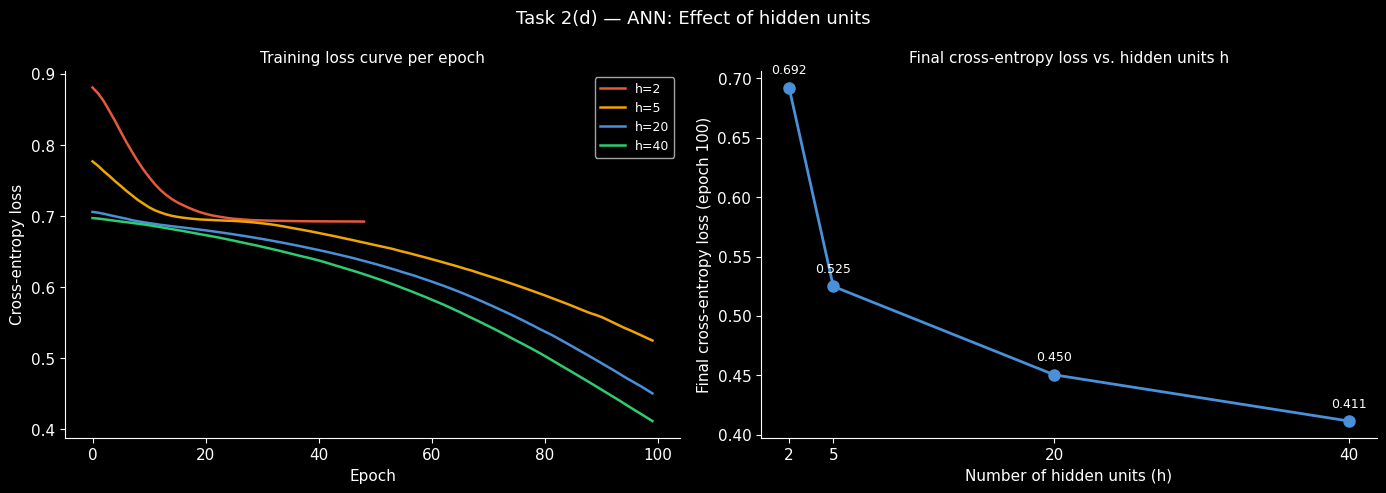

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: loss curve per epoch for each h
colors_h = ['#E8593C', '#F0A500', '#4A90D9', '#2ECC71']
for (h, curve), c in zip(ann_loss_curves.items(), colors_h):
    axes[0].plot(curve, label=f'h={h}', color=c, linewidth=1.8)
axes[0].set_title('Training loss curve per epoch', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot 2: final loss vs h (as required by Task 2d)
h_vals   = list(ann_losses.keys())
loss_vals = list(ann_losses.values())
axes[1].plot(h_vals, loss_vals, marker='o', color='#4A90D9',
             linewidth=2, markersize=8)
for hv, lv in zip(h_vals, loss_vals):
    axes[1].annotate(f'{lv:.3f}', (hv, lv),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=9)
axes[1].set_title('Final cross-entropy loss vs. hidden units h', fontsize=11)
axes[1].set_xlabel('Number of hidden units (h)')
axes[1].set_ylabel('Final cross-entropy loss (epoch 100)')
axes[1].set_xticks(h_vals)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Task 2(d) — ANN: Effect of hidden units', fontsize=13)
plt.tight_layout()
plt.savefig('task2d_ann.png', bbox_inches='tight', dpi=120)
plt.show()

**Task 2(d) Analysis:**

- More hidden units give the network greater **capacity** (ability to fit complex patterns), typically leading to lower training loss.
- However, very small h (e.g. h=2) may underfit — the network cannot represent the required decision function.
- h=20 and h=40 generally achieve lower final loss, but training loss alone doesn't tell us about generalization — see Task 3 for test performance.

<a id='task3'></a>
## Task 3: Classification Quality Evaluation

<a id='3a'></a>
### Task 3(a) — Hyperparameter tuning via 5-fold cross-validation

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_f1(estimator, X, y):
    """Return mean macro F1 over 5-fold CV."""
    scores = cross_val_score(estimator, X, y, cv=cv,
                             scoring='f1_macro', n_jobs=-1)
    return scores.mean(), scores.std()

In [24]:
# ── 3a-i: NB — vary alpha (Laplace smoothing) ─────────────────
nb_alphas  = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
nb_cv_mean = []
nb_cv_std  = []
for a in nb_alphas:
    m, s = cv_f1(MultinomialNB(alpha=a), X_train, y_train)
    nb_cv_mean.append(m)
    nb_cv_std.append(s)
    print(f'NB  alpha={a:6.3f}  CV F1={m:.4f} ± {s:.4f}')

best_nb_alpha = nb_alphas[np.argmax(nb_cv_mean)]
print(f'\nBest NB alpha: {best_nb_alpha}')

NB  alpha= 0.001  CV F1=0.9696 ± 0.0160
NB  alpha= 0.010  CV F1=0.9766 ± 0.0105
NB  alpha= 0.100  CV F1=0.9860 ± 0.0136
NB  alpha= 0.500  CV F1=0.9837 ± 0.0174
NB  alpha= 1.000  CV F1=0.9837 ± 0.0174
NB  alpha= 2.000  CV F1=0.9790 ± 0.0200
NB  alpha= 5.000  CV F1=0.9743 ± 0.0201
NB  alpha=10.000  CV F1=0.9719 ± 0.0217

Best NB alpha: 0.1


In [25]:
# ── 3a-ii: kNN — vary k and metric ────────────────────────────
k_values = [1, 3, 5, 7, 10, 15, 20, 30]
metrics  = ['euclidean', 'cosine']
knn_results = {}

for metric in metrics:
    knn_results[metric] = []
    for k in k_values:
        m, s = cv_f1(KNeighborsClassifier(n_neighbors=k, metric=metric),
                     X_train, y_train)
        knn_results[metric].append((m, s))
        print(f'kNN  k={k:2d}  metric={metric:10s}  CV F1={m:.4f} ± {s:.4f}')

best_k = k_values[np.argmax([r[0] for r in knn_results['euclidean']])]
best_metric = max(metrics, key=lambda mt:
                  max(r[0] for r in knn_results[mt]))
print(f'\nBest kNN: k={best_k}, metric={best_metric}')

kNN  k= 1  metric=euclidean   CV F1=0.9486 ± 0.0272
kNN  k= 3  metric=euclidean   CV F1=0.9743 ± 0.0088
kNN  k= 5  metric=euclidean   CV F1=0.9743 ± 0.0136
kNN  k= 7  metric=euclidean   CV F1=0.9743 ± 0.0249
kNN  k=10  metric=euclidean   CV F1=0.9766 ± 0.0165
kNN  k=15  metric=euclidean   CV F1=0.9743 ± 0.0201
kNN  k=20  metric=euclidean   CV F1=0.9790 ± 0.0154
kNN  k=30  metric=euclidean   CV F1=0.9790 ± 0.0187
kNN  k= 1  metric=cosine      CV F1=0.9486 ± 0.0272
kNN  k= 3  metric=cosine      CV F1=0.9743 ± 0.0088
kNN  k= 5  metric=cosine      CV F1=0.9743 ± 0.0136
kNN  k= 7  metric=cosine      CV F1=0.9743 ± 0.0249
kNN  k=10  metric=cosine      CV F1=0.9766 ± 0.0165
kNN  k=15  metric=cosine      CV F1=0.9743 ± 0.0201
kNN  k=20  metric=cosine      CV F1=0.9790 ± 0.0154
kNN  k=30  metric=cosine      CV F1=0.9790 ± 0.0187

Best kNN: k=20, metric=euclidean


In [26]:
# ── 3a-iii: SVM — vary kernel and C ───────────────────────────
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
kernels  = ['linear', 'rbf']
svm_results = {}

for kernel in kernels:
    svm_results[kernel] = []
    for C in C_values:
        m, s = cv_f1(SVC(kernel=kernel, C=C, random_state=RANDOM_STATE),
                     X_train, y_train)
        svm_results[kernel].append((m, s))
        print(f'SVM  kernel={kernel:6s}  C={C:6.2f}  CV F1={m:.4f} ± {s:.4f}')

best_C_linear = C_values[np.argmax([r[0] for r in svm_results['linear']])]
best_C_rbf    = C_values[np.argmax([r[0] for r in svm_results['rbf']])]
best_kernel   = max(kernels, key=lambda k: max(r[0] for r in svm_results[k]))
best_C_svm    = best_C_linear if best_kernel == 'linear' else best_C_rbf
print(f'\nBest SVM: kernel={best_kernel}, C={best_C_svm}')

SVM  kernel=linear  C=  0.01  CV F1=0.3354 ± 0.0019
SVM  kernel=linear  C=  0.10  CV F1=0.9483 ± 0.0192
SVM  kernel=linear  C=  1.00  CV F1=0.9906 ± 0.0115
SVM  kernel=linear  C= 10.00  CV F1=0.9883 ± 0.0105
SVM  kernel=linear  C=100.00  CV F1=0.9883 ± 0.0105
SVM  kernel=rbf     C=  0.01  CV F1=0.3354 ± 0.0019
SVM  kernel=rbf     C=  0.10  CV F1=0.3354 ± 0.0019
SVM  kernel=rbf     C=  1.00  CV F1=0.9906 ± 0.0115
SVM  kernel=rbf     C= 10.00  CV F1=0.9883 ± 0.0105
SVM  kernel=rbf     C=100.00  CV F1=0.9883 ± 0.0105

Best SVM: kernel=linear, C=1.0


In [27]:
# ── 3a-iv: ANN — vary hidden units and learning rate ──────────
hidden_units_cv = [2, 5, 10, 20, 40, 80]
lr_values       = [0.001, 0.01, 0.1]
ann_results     = {}

for lr in lr_values:
    ann_results[lr] = []
    for h in hidden_units_cv:
        m, s = cv_f1(
            MLPClassifier(hidden_layer_sizes=(h,), solver='sgd',
                          learning_rate_init=lr, max_iter=100,
                          random_state=RANDOM_STATE),
            X_train, y_train
        )
        ann_results[lr].append((m, s))
        print(f'ANN  h={h:2d}  lr={lr}  CV F1={m:.4f} ± {s:.4f}')

best_h  = hidden_units_cv[np.argmax([r[0] for r in ann_results[0.01]])]
best_lr = max(lr_values, key=lambda lr: max(r[0] for r in ann_results[lr]))
print(f'\nBest ANN: h={best_h}, lr={best_lr}')

ANN  h= 2  lr=0.001  CV F1=0.3312 ± 0.0020
ANN  h= 5  lr=0.001  CV F1=0.3354 ± 0.0019
ANN  h=10  lr=0.001  CV F1=0.4521 ± 0.0384
ANN  h=20  lr=0.001  CV F1=0.3312 ± 0.0020
ANN  h=40  lr=0.001  CV F1=0.3312 ± 0.0020
ANN  h=80  lr=0.001  CV F1=0.3312 ± 0.0020
ANN  h= 2  lr=0.01  CV F1=0.5077 ± 0.1219
ANN  h= 5  lr=0.01  CV F1=0.7248 ± 0.1974
ANN  h=10  lr=0.01  CV F1=0.9602 ± 0.0159
ANN  h=20  lr=0.01  CV F1=0.9743 ± 0.0200
ANN  h=40  lr=0.01  CV F1=0.9837 ± 0.0174
ANN  h=80  lr=0.01  CV F1=0.9649 ± 0.0257
ANN  h= 2  lr=0.1  CV F1=0.8596 ± 0.2635
ANN  h= 5  lr=0.1  CV F1=0.9883 ± 0.0148
ANN  h=10  lr=0.1  CV F1=0.9906 ± 0.0115
ANN  h=20  lr=0.1  CV F1=0.9906 ± 0.0115
ANN  h=40  lr=0.1  CV F1=0.9930 ± 0.0094
ANN  h=80  lr=0.1  CV F1=0.9930 ± 0.0094

Best ANN: h=40, lr=0.1


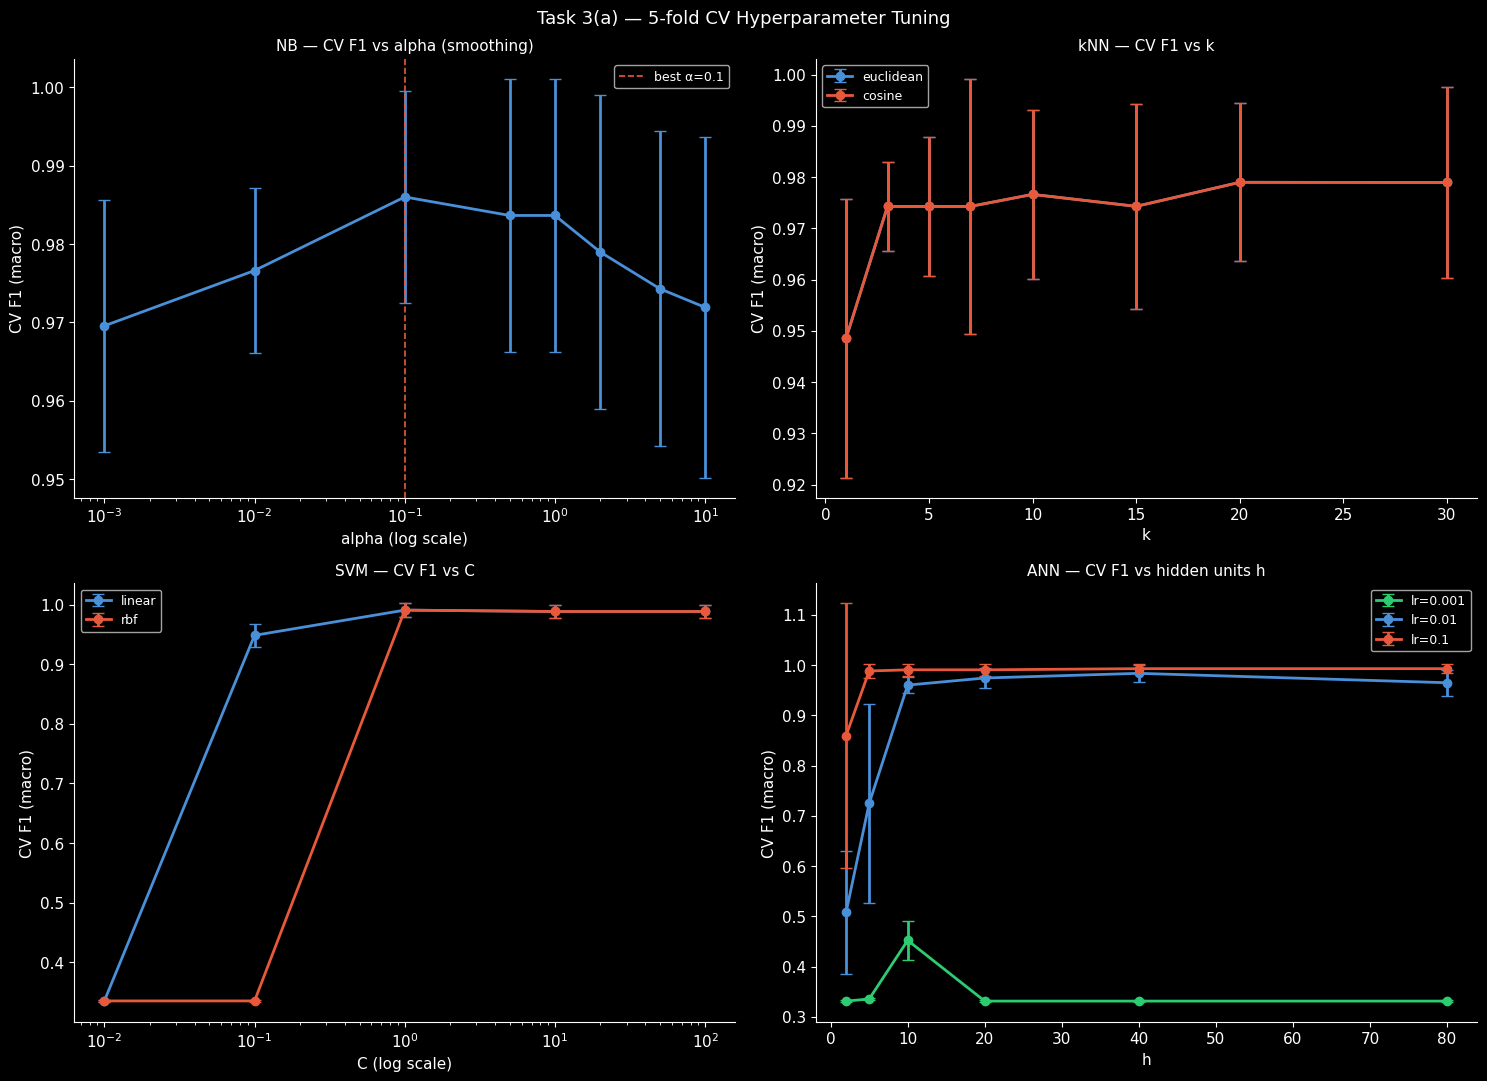

In [28]:
# ── Plot CV results for all four models ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# NB
ax = axes[0, 0]
ax.errorbar(nb_alphas, nb_cv_mean, yerr=nb_cv_std,
            marker='o', color='#4A90D9', capsize=4, linewidth=2)
ax.axvline(best_nb_alpha, color='#E8593C', linestyle='--', linewidth=1.2,
           label=f'best α={best_nb_alpha}')
ax.set_xscale('log')
ax.set_title('NB — CV F1 vs alpha (smoothing)', fontsize=11)
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('CV F1 (macro)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# kNN
ax = axes[0, 1]
for metric, c in zip(metrics, ['#4A90D9', '#E8593C']):
    means = [r[0] for r in knn_results[metric]]
    stds  = [r[1] for r in knn_results[metric]]
    ax.errorbar(k_values, means, yerr=stds, marker='o', color=c,
                capsize=4, linewidth=2, label=metric)
ax.set_title('kNN — CV F1 vs k', fontsize=11)
ax.set_xlabel('k'); ax.set_ylabel('CV F1 (macro)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# SVM
ax = axes[1, 0]
for kernel, c in zip(kernels, ['#4A90D9', '#E8593C']):
    means = [r[0] for r in svm_results[kernel]]
    stds  = [r[1] for r in svm_results[kernel]]
    ax.errorbar(C_values, means, yerr=stds, marker='o', color=c,
                capsize=4, linewidth=2, label=kernel)
ax.set_xscale('log')
ax.set_title('SVM — CV F1 vs C', fontsize=11)
ax.set_xlabel('C (log scale)'); ax.set_ylabel('CV F1 (macro)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ANN
ax = axes[1, 1]
palette_lr = {0.001: '#2ECC71', 0.01: '#4A90D9', 0.1: '#E8593C'}
for lr in lr_values:
    means = [r[0] for r in ann_results[lr]]
    stds  = [r[1] for r in ann_results[lr]]
    ax.errorbar(hidden_units_cv, means, yerr=stds, marker='o',
                color=palette_lr[lr], capsize=4, linewidth=2, label=f'lr={lr}')
ax.set_title('ANN — CV F1 vs hidden units h', fontsize=11)
ax.set_xlabel('h'); ax.set_ylabel('CV F1 (macro)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Task 3(a) — 5-fold CV Hyperparameter Tuning', fontsize=13)
plt.tight_layout()
plt.savefig('task3a_cv.png', bbox_inches='tight', dpi=120)
plt.show()

**Task 3(a) Observations:** [Describe each subplot — e.g. which alpha/k/C/h gives best CV F1, and what the trend looks like]

<a id='3b'></a>
### Task 3(b) — Best models: test F1 comparison

In [29]:
# ── Train best models on full training set ────────────────────
best_nb  = MultinomialNB(alpha=best_nb_alpha)
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
best_svm = SVC(kernel=best_kernel, C=best_C_svm, random_state=RANDOM_STATE)
best_ann = MLPClassifier(
    hidden_layer_sizes=(best_h,), solver='sgd',
    learning_rate_init=best_lr, max_iter=100,
    random_state=RANDOM_STATE
)

best_models = {
    'Naive Bayes': best_nb,
    'kNN':         best_knn,
    'SVM':         best_svm,
    'ANN':         best_ann,
}

results_3b = {}
for name, model in best_models.items():
    model.fit(X_train, y_train)
    f1_tr = f1_score(y_train, model.predict(X_train), average='macro')
    f1_te = f1_score(y_test,  model.predict(X_test),  average='macro')
    results_3b[name] = {'train_f1': round(f1_tr, 4), 'test_f1': round(f1_te, 4)}
    print(f'{name:15s}  train F1={f1_tr:.4f}  test F1={f1_te:.4f}')

Naive Bayes      train F1=0.9953  test F1=0.9808
kNN              train F1=0.9790  test F1=0.9711
SVM              train F1=1.0000  test F1=1.0000
ANN              train F1=1.0000  test F1=0.9904


In [30]:
# Detailed classification report for each best model
for name, model in best_models.items():
    print(f'\n── {name} ──')
    print(classification_report(y_test, model.predict(X_test)))


── Naive Bayes ──
               precision    recall  f1-score   support

entertainment       1.00      0.97      0.98        61
         tech       0.96      1.00      0.98        45

     accuracy                           0.98       106
    macro avg       0.98      0.98      0.98       106
 weighted avg       0.98      0.98      0.98       106


── kNN ──
               precision    recall  f1-score   support

entertainment       0.98      0.97      0.98        61
         tech       0.96      0.98      0.97        45

     accuracy                           0.97       106
    macro avg       0.97      0.97      0.97       106
 weighted avg       0.97      0.97      0.97       106


── SVM ──
               precision    recall  f1-score   support

entertainment       1.00      1.00      1.00        61
         tech       1.00      1.00      1.00        45

     accuracy                           1.00       106
    macro avg       1.00      1.00      1.00       106
 weighted avg   

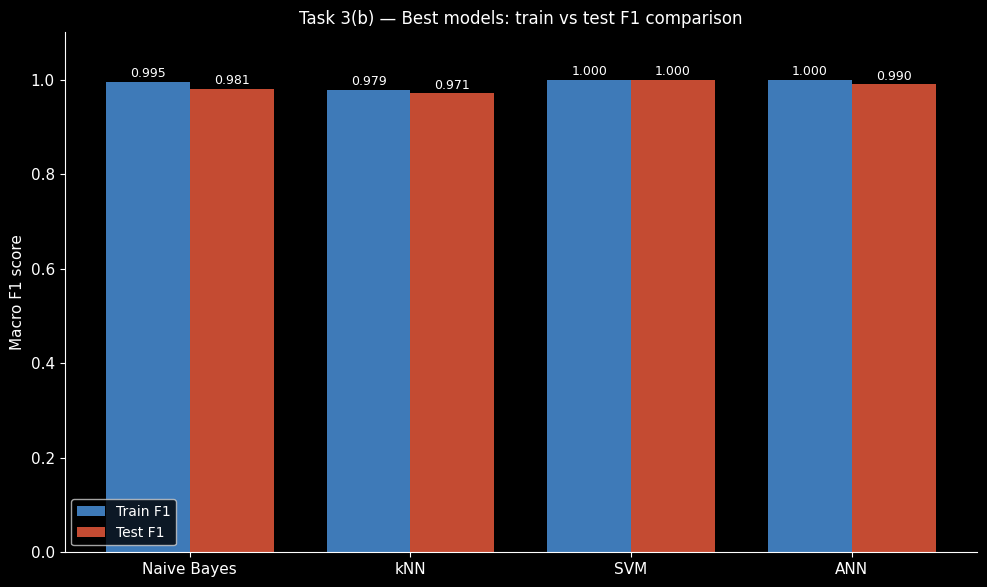

In [31]:
# ── Bar chart: test F1 comparison ────────────────────────────
model_names = list(results_3b.keys())
test_f1s    = [results_3b[n]['test_f1']  for n in model_names]
train_f1s   = [results_3b[n]['train_f1'] for n in model_names]

x    = np.arange(len(model_names))
w    = 0.38
fig, ax = plt.subplots(figsize=(10, 6))

b1 = ax.bar(x - w/2, train_f1s, w, label='Train F1', color='#4A90D9', alpha=0.85)
b2 = ax.bar(x + w/2, test_f1s,  w, label='Test F1',  color='#E8593C', alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Macro F1 score')
ax.set_title('Task 3(b) — Best models: train vs test F1 comparison', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('task3b_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

**Task 3(b) Summary:** [Compare F1 scores — which model performs best and why? Note any large train/test gap indicating overfitting.]

<a id='3c'></a>
### Task 3(c) — Learning curves: effect of training set size

In [32]:
# ── Learning curves with m ∈ [0.1, 0.3, 0.5, 0.7, 0.9] ───────
# IMPORTANT: use data[0:mN] sequential slice, NOT random sample

m_values = [0.1, 0.3, 0.5, 0.7, 0.9]
N        = X_train.shape[0]

learning_curve_results = {
    name: {'train': [], 'test': []} for name in best_models
}

for m in m_values:
    n     = max(int(m * N), 10)   # at least 10 samples
    X_sub = X_train[:n]
    y_sub = y_train[:n]
    print(f'm={m:.1f}  n={n}  classes in subset: {np.unique(y_sub)}')

    for name, model in best_models.items():
        model.fit(X_sub, y_sub)
        f1_tr = f1_score(y_sub,   model.predict(X_sub),  average='macro')
        f1_te = f1_score(y_test,  model.predict(X_test), average='macro')
        learning_curve_results[name]['train'].append(f1_tr)
        learning_curve_results[name]['test'].append(f1_te)
        print(f'  {name:15s}  train F1={f1_tr:.4f}  test F1={f1_te:.4f}')

# Retrain best models on FULL training set after this experiment
for model in best_models.values():
    model.fit(X_train, y_train)

m=0.1  n=42  classes in subset: ['entertainment' 'tech']
  Naive Bayes      train F1=1.0000  test F1=0.9147
  kNN              train F1=0.7772  test F1=0.7821
  SVM              train F1=1.0000  test F1=0.9241
  ANN              train F1=1.0000  test F1=0.9147
m=0.3  n=128  classes in subset: ['entertainment' 'tech']
  Naive Bayes      train F1=1.0000  test F1=0.9713
  kNN              train F1=0.9765  test F1=0.9618
  SVM              train F1=1.0000  test F1=0.9904
  ANN              train F1=1.0000  test F1=1.0000
m=0.5  n=214  classes in subset: ['entertainment' 'tech']
  Naive Bayes      train F1=1.0000  test F1=0.9713
  kNN              train F1=0.9766  test F1=0.9904
  SVM              train F1=1.0000  test F1=0.9904
  ANN              train F1=1.0000  test F1=1.0000
m=0.7  n=299  classes in subset: ['entertainment' 'tech']
  Naive Bayes      train F1=0.9967  test F1=0.9713
  kNN              train F1=0.9731  test F1=0.9808
  SVM              train F1=1.0000  test F1=0.9808
  AN

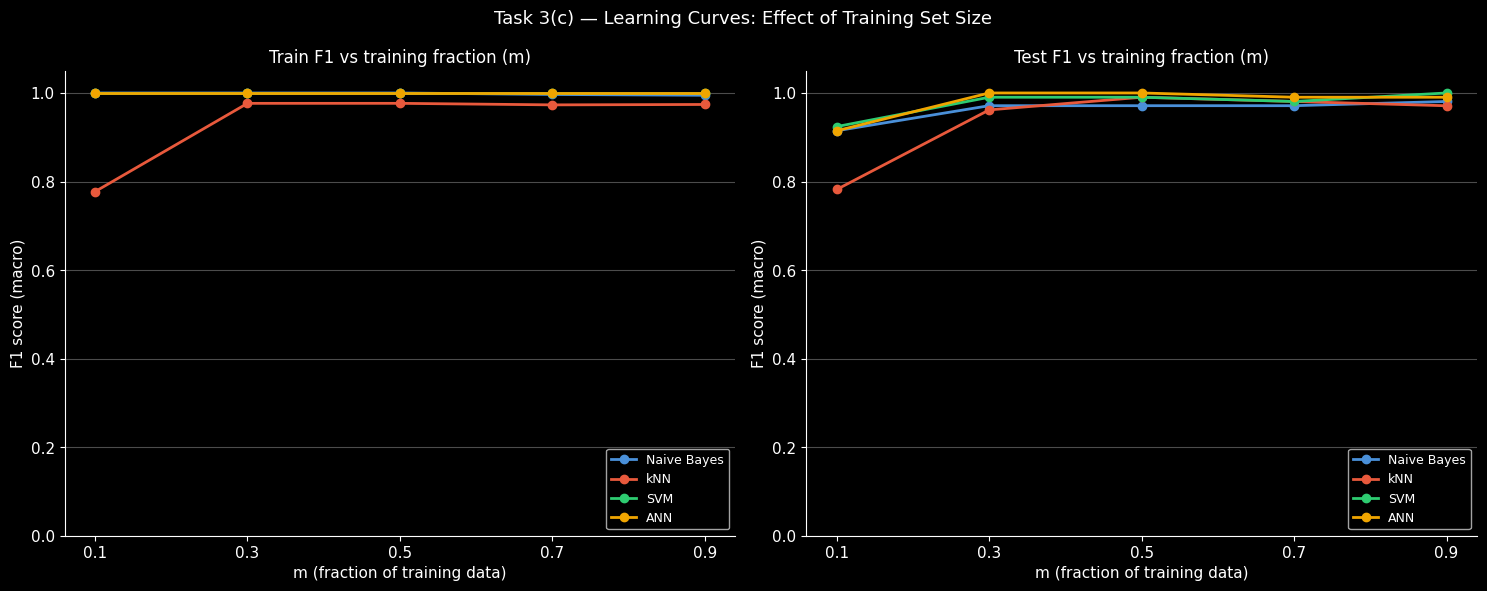

In [33]:
# ── Plot learning curves ──────────────────────────────────────
model_colors = {
    'Naive Bayes': '#4A90D9',
    'kNN':         '#E8593C',
    'SVM':         '#2ECC71',
    'ANN':         '#F0A500',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

for name, color in model_colors.items():
    axes[0].plot(m_values, learning_curve_results[name]['train'],
                 marker='o', label=name, color=color, linewidth=2)
    axes[1].plot(m_values, learning_curve_results[name]['test'],
                 marker='o', label=name, color=color, linewidth=2)

for ax, split in zip(axes, ['Train F1', 'Test F1']):
    ax.set_title(f'{split} vs training fraction (m)', fontsize=12)
    ax.set_xlabel('m (fraction of training data)')
    ax.set_ylabel(f'F1 score (macro)')
    ax.set_xticks(m_values)
    ax.set_xticklabels([str(m) for m in m_values])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Task 3(c) — Learning Curves: Effect of Training Set Size', fontsize=13)
plt.tight_layout()
plt.savefig('task3c_learning_curves.png', bbox_inches='tight', dpi=120)
plt.show()

**Task 3(c) Analysis:**

- **Train F1 (left plot):** Generally decreases as m increases for most models. With very few samples, it's easy to achieve near-perfect training accuracy. As more diverse data is added, it becomes harder to fit perfectly.

- **Test F1 (right plot):** Generally increases as m increases — more training data improves generalization. The gap between train and test F1 narrows with more data, indicating reduced overfitting.

- **kNN** tends to overfit strongly at small m (train F1 ≈ 1 with k=1), while **Naive Bayes** is typically more stable due to its strong independence assumption (lower variance).

- **SVM and ANN** may show slower improvement but reach higher plateaus at large m, reflecting their greater model capacity.